# Counterfactual Generation with Certified Polyhedral Projection (CPP)

This notebook demonstrates the **Certified Polyhedral Projection (CPP)** algorithm for generating robust counterfactual explanations.

## Overview

Given a query point $x_{query}$ from class $A$, we want to find the closest certified point in class $B$.

Unlike gradient-based methods that navigate non-convex loss landscapes, CPP:
1. Projects onto pre-computed certified polytopes (offline phase)
2. Solves convex QPs with global optimality guarantees
3. Returns counterfactuals with mathematical validity certificates

## Algorithm

**Phase I (Offline)**: Build polytope atlas for target class
- Already computed in Notebook 2 using LiRPA

**Phase II (Online)**: Generate counterfactual
1. Find k-nearest polytopes in target class
2. Project query onto each (solve convex QP)
3. Return projection with minimum distance

## 1 – Setup

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from preimage_sampling import SimpleClassifier, PreimageApproximation, CounterfactualSampler
from preimage_sampling.geometry import build_class_union
from preimage_sampling.visualization import plot_geom
from preimage_sampling.utils import load_model

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2 – Load Data and Model

In [2]:
# Load test dataset
test_dataset = torch.load('test_spiral.pt', weights_only=True)

# Group by label for easy access
label_dataset = {}
for img, label in test_dataset:
    label_dataset.setdefault(label.item(), []).append(img)
label_dataset = {k: torch.stack(v) for k, v in label_dataset.items()}

n_classes = len(label_dataset)
print(f'{n_classes} classes | total samples: {sum(v.size(0) for v in label_dataset.values())}')

10 classes | total samples: 400


In [3]:
# Load trained model
model = SimpleClassifier()
model = load_model(model, 'mnist_simple_classifier.pth', device=device)
print(model)

SimpleClassifier(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=10, bias=True)
  )
)


## 3 – Compute LiRPA Bounds (Offline Phase)

This constructs the certified polytope atlas for each class.

In [4]:
EPS = 0.05  # Perturbation radius
N_PER_CLASS = 40  # Number of samples per class to use

# Compute bounds
approximator = PreimageApproximation(model, test_dataset, device, cnn=False)
all_bounds = approximator.compute_all_bounds(eps=EPS, norm=2, max_samples_per_class=N_PER_CLASS)

print("\nBounds computed for all classes:")
for label in all_bounds:
    print(f"  Class {label}: {all_bounds[label]['lA'].shape[0]} polytopes")

Computing bounds: 100%|██████████| 10/10 [00:00<00:00, 23.88it/s]


Bounds computed for all classes:
  Class 0: 40 polytopes
  Class 1: 40 polytopes
  Class 2: 40 polytopes
  Class 3: 40 polytopes
  Class 4: 40 polytopes
  Class 5: 40 polytopes
  Class 6: 40 polytopes
  Class 7: 40 polytopes
  Class 8: 40 polytopes
  Class 9: 40 polytopes


## 4 – Build Counterfactual Sampler

Initialize the CPP sampler with the computed bounds.

In [5]:
sampler = CounterfactualSampler(solver='ECOS', verbose=True)
sampler.build_all_atlases(all_bounds, eps=EPS)

print(f"\nSampler ready with {len(sampler.atlases)} class atlases")

Built atlas for class 0: 40 polytopes, dim=2, eps=0.05
Built atlas for class 1: 40 polytopes, dim=2, eps=0.05
Built atlas for class 2: 40 polytopes, dim=2, eps=0.05
Built atlas for class 3: 40 polytopes, dim=2, eps=0.05
Built atlas for class 4: 40 polytopes, dim=2, eps=0.05
Built atlas for class 5: 40 polytopes, dim=2, eps=0.05
Built atlas for class 6: 40 polytopes, dim=2, eps=0.05
Built atlas for class 7: 40 polytopes, dim=2, eps=0.05
Built atlas for class 8: 40 polytopes, dim=2, eps=0.05
Built atlas for class 9: 40 polytopes, dim=2, eps=0.05
Built 10 atlases

Sampler ready with 10 class atlases


## 5 – Generate Single Counterfactual

Let's take a query point from class 0 and generate a counterfactual for class 5.

In [6]:
# Select query point from class 0
source_class = 0
target_class = 5
query_idx = 0

x_query = all_bounds[source_class]['X'][query_idx]
print(f"Query point from class {source_class}: {x_query}")

# Generate counterfactual
result = sampler.generate_counterfactual(
    x_query,
    target_label=target_class,
    k_candidates=10,
    return_all_candidates=True
)

if result['success']:
    print(f"\n✓ SUCCESS: Found counterfactual at distance {result['distance']:.4f}")
    print(f"  Counterfactual point: {result['counterfactual']}")
    print(f"  Feasible projections: {result['n_candidates_feasible']}/{result['n_candidates_tried']}")
else:
    print(f"\n✗ FAILED: Could not find feasible counterfactual")

Query point from class 0: [0.37120986 0.02196775]
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.1659, feasible=10/10

✓ SUCCESS: Found counterfactual at distance 0.1659
  Counterfactual point: [ 0.23747952 -0.07625624]
  Feasible projections: 10/10


## 6 – Verify Counterfactual

Check that the model actually classifies the counterfactual as the target class.

In [7]:
if result['success']:
    verification = sampler.verify_counterfactual(
        result['counterfactual'],
        target_label=target_class,
        model=model,
        device=device
    )
    
    print(f"Model prediction: class {verification['predicted_label']}")
    print(f"Target class: {verification['target_label']}")
    print(f"Correct: {verification['correct']}")
    print(f"\nTop-3 probabilities:")
    
    top3 = np.argsort(verification['probabilities'])[-3:][::-1]
    for i in top3:
        print(f"  Class {i}: {verification['probabilities'][i]:.4f}")

Model prediction: class 5
Target class: 5
Correct: True

Top-3 probabilities:
  Class 5: 0.5952
  Class 8: 0.4047
  Class 2: 0.0001


## 7 – Visualize Counterfactual

Plot the query point, counterfactual, and the certified regions.

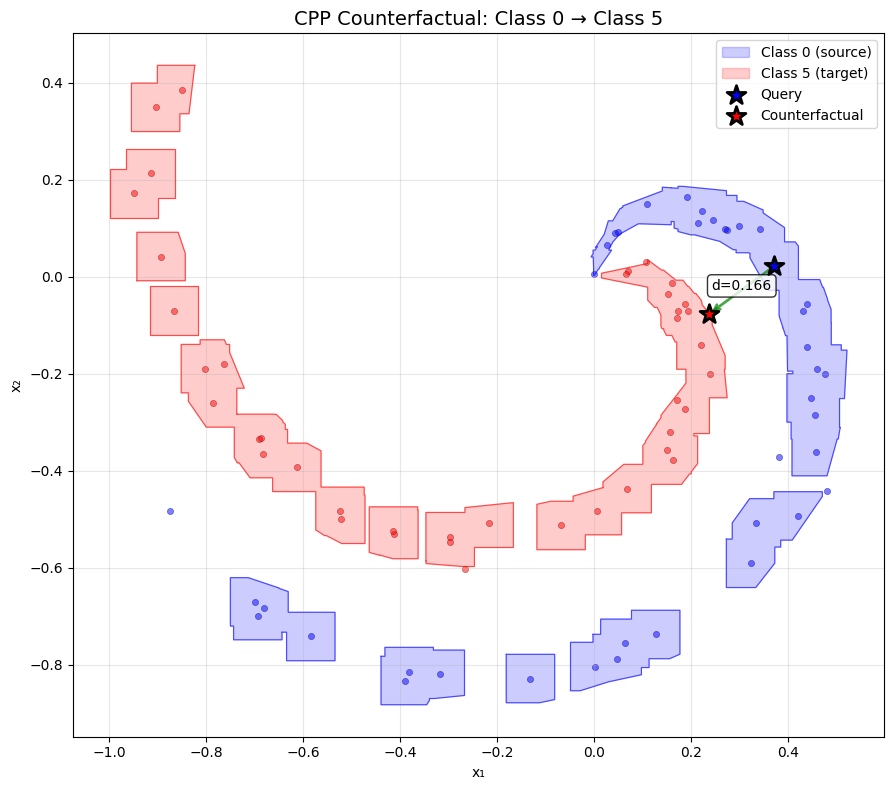

In [8]:
if result['success']:
    # Build class unions for visualization
    union_source = build_class_union(source_class, all_bounds, EPS)
    union_target = build_class_union(target_class, all_bounds, EPS)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot certified regions
    plot_geom(ax, union_source, color='blue', alpha=0.2, label=f'Class {source_class} (source)')
    plot_geom(ax, union_target, color='red', alpha=0.2, label=f'Class {target_class} (target)')
    
    # Plot sample points
    ax.scatter(all_bounds[source_class]['X'][:, 0], all_bounds[source_class]['X'][:, 1],
               s=20, alpha=0.5, color='blue', edgecolors='darkblue', linewidth=0.5)
    ax.scatter(all_bounds[target_class]['X'][:, 0], all_bounds[target_class]['X'][:, 1],
               s=20, alpha=0.5, color='red', edgecolors='darkred', linewidth=0.5)
    
    # Plot query point
    ax.scatter(*x_query, s=200, color='blue', marker='*', 
               edgecolors='black', linewidth=2, label='Query', zorder=5)
    
    # Plot counterfactual
    x_cf = result['counterfactual']
    ax.scatter(*x_cf, s=200, color='red', marker='*',
               edgecolors='black', linewidth=2, label='Counterfactual', zorder=5)
    
    # Draw arrow from query to counterfactual
    ax.annotate('', xy=x_cf, xytext=x_query,
                arrowprops=dict(arrowstyle='->', lw=2, color='green', alpha=0.7))
    
    # Add distance annotation
    mid_point = (x_query + x_cf) / 2
    ax.text(mid_point[0], mid_point[1], f"d={result['distance']:.3f}",
            fontsize=10, ha='center', bbox=dict(boxstyle='round,pad=0.3', 
                                                 facecolor='white', alpha=0.8))
    
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=10)
    ax.set_title(f'CPP Counterfactual: Class {source_class} → Class {target_class}', fontsize=14)
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8 – Generate Multiple Counterfactuals

Generate counterfactuals for multiple query points in batch.

In [9]:
# Select multiple query points from class 0
n_queries = 5
X_queries = all_bounds[source_class]['X'][:n_queries]
target_labels = np.full(n_queries, target_class)

# Generate counterfactuals in batch
results = sampler.generate_counterfactual_batch(
    X_queries,
    target_labels,
    k_candidates=10
)

# Print results
print(f"Generated {len(results)} counterfactuals:\n")
for i, result in enumerate(results):
    status = '✓' if result['success'] else '✗'
    dist = result['distance'] if result['success'] else 'N/A'
    print(f"{status} Query {i}: distance={dist}")

Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.1659, feasible=10/10
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.2163, feasible=10/10
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.1358, feasible=10/10
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.1732, feasible=10/10
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.1886, feasible=10/10
Generated 5 counterfactuals:

✓ Query 0: distance=0.16592695539296712
✓ Query 1: distance=0.2163156175093947
✓ Query 2: distance=0.13582434049950692
✓ Query 3: distance=0.17319266809187095
✓ Query 4: distance=0.18861305193746222


## 9 – Compare with All Target Classes

For a single query, find the closest counterfactual across all target classes.

In [10]:
x_query = all_bounds[source_class]['X'][0]

print(f"Finding closest counterfactual from class {source_class} to all other classes:\n")

best_result = None
best_distance = np.inf

for target in range(n_classes):
    if target == source_class:
        continue
    
    result = sampler.generate_counterfactual(
        x_query,
        target_label=target,
        k_candidates=10
    )
    
    if result['success']:
        print(f"  Class {target}: distance={result['distance']:.4f}")
        
        if result['distance'] < best_distance:
            best_distance = result['distance']
            best_result = result
    else:
        print(f"  Class {target}: NO FEASIBLE COUNTERFACTUAL")

if best_result:
    print(f"\nClosest counterfactual: class {best_result['target_label']} at distance {best_distance:.4f}")

Finding closest counterfactual from class 0 to all other classes:

Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.3738, feasible=10/10
  Class 1: distance=0.3738
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.2553, feasible=10/10
  Class 2: distance=0.2553
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.0742, feasible=10/10
  Class 3: distance=0.0742
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.3717, feasible=10/10
  Class 4: distance=0.3717
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.1659, feasible=10/10
  Class 5: distance=0.1659
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.1865, feasible=10/10
  Class 6: distance=0.1865
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.3507, feasible=10/10
  Class 7: distance=0.3507
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.0501, feasible=10/10
  Class 8: distance=0.0501
Selected 10 nearest polytopes from 40

## 10 – Distance Distribution Analysis

Analyze the distribution of counterfactual distances.

Generating counterfactuals for 40 queries from class 0 to class 5...
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.1659, feasible=10/10
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.2163, feasible=10/10
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.1358, feasible=10/10
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.1732, feasible=10/10
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.1886, feasible=10/10
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.1948, feasible=10/10
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.2198, feasible=10/10
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.2021, feasible=10/10
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.1388, feasible=10/10
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.1895, feasible=10/10
Selected 10 nearest polytopes from 40 total
SUCCESS: distance=0.1516, feasible=10

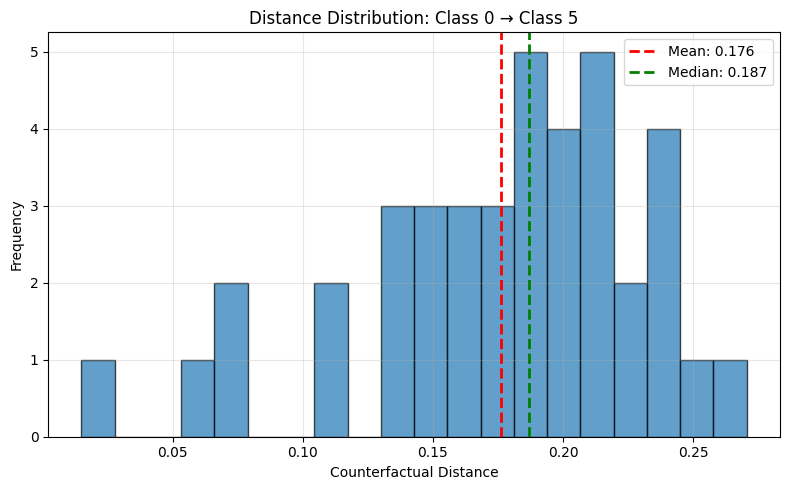

In [11]:
# Generate counterfactuals for all samples in source class
all_queries = all_bounds[source_class]['X']
n_total = len(all_queries)

distances = []
success_count = 0

print(f"Generating counterfactuals for {n_total} queries from class {source_class} to class {target_class}...")

for x_query in all_queries:
    result = sampler.generate_counterfactual(
        x_query,
        target_label=target_class,
        k_candidates=10
    )
    
    if result['success']:
        distances.append(result['distance'])
        success_count += 1

distances = np.array(distances)

print(f"\nSuccess rate: {success_count}/{n_total} ({100*success_count/n_total:.1f}%)")
if len(distances) > 0:
    print(f"Distance statistics:")
    print(f"  Mean: {distances.mean():.4f}")
    print(f"  Median: {np.median(distances):.4f}")
    print(f"  Min: {distances.min():.4f}")
    print(f"  Max: {distances.max():.4f}")
    print(f"  Std: {distances.std():.4f}")
    
    # Plot histogram
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(distances, bins=20, edgecolor='black', alpha=0.7)
    ax.axvline(distances.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {distances.mean():.3f}')
    ax.axvline(np.median(distances), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(distances):.3f}')
    ax.set_xlabel('Counterfactual Distance')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distance Distribution: Class {source_class} → Class {target_class}')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Conclusion

This notebook demonstrated the **Certified Polyhedral Projection (CPP)** algorithm for counterfactual generation.

Key takeaways:
1. **Guaranteed validity**: All counterfactuals lie within certified regions
2. **Convex optimization**: Each projection is a convex QP with global optimality
3. **Efficiency**: Pre-computed polytopes enable fast online queries
4. **Manifold adherence**: Counterfactuals stay near real data distribution

### Advantages over gradient-based methods:
- No local minima issues
- Mathematical validity guarantees
- More interpretable (geometric projection)
- Deterministic results (no random initialization)

### Trade-offs:
- Offline computation required (LiRPA bounds)
- Distance may be slightly larger than uncertified methods
- Memory scales with number of training samples